<a href="https://colab.research.google.com/github/mudather490/heart-disease-risk-prediction/blob/main/logistiic_Regrission_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve




In [ ]:
path = '/content/drive/MyDrive/Datasate/framingham.csv'
df = pd.read_csv(path)
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
#EDA

df.shape

(4238, 16)

In [ ]:
#EDA
df.info



<bound method DataFrame.info of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4233     1   50        1.0              1         1.0     0.0   
4234     1   51        3.0              1        43.0     0.0   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0   81.0  28.73   
2                   0             0         0    245.0  127.5   80.0  25.34   
3                   0             1         0    225.0  150.0   95.0  28.58   
4                   0             0         0    285.0  130.0   84.0  23.10   
...               ...           ...       ...      ...    ...    ...    ...   
4233                0             1         0    313.0  179.0   92.0  25.97   
4234                0             0         0    207.0  126.5   80.0  19.71   
4235                0             0         0    248.0  131.0   72.0  22.00   
4236                0             0         0    210.0  126.5   87.0  19.16   
4237                0             0         0    269.0  133.5   83.0  21.47   

      heartRate  glucose  TenYearCHD  
0          80.0     77.0           0  
1          95.0     76.0           0  
2          75.0     70.0           0  
3          65.0    103.0           1  
4          85.0     85.0           0  
...         ...      ...         ...  
4233       66.0     86.0           1  
4234       65.0     68.0           0  
4235       84.0     86.0           0  
4236       86.0      NaN           0  
4237       80.0    107.0           0  

[4238 rows x 16 columns]>

In [ ]:
#EDA
df.info

df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
# Chack for messing values
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
# Clean the data
df_clean = df.dropna()
print (df_clean)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4231     1   58        3.0              0         0.0     0.0   
4232     1   68        1.0              0         0.0     0.0   
4233     1   50        1.0              1         1.0     0.0   
4234     1   51        3.0              1        43.0     0.0   
4237     0   52        2.0              0         0.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

Target Class Distribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64


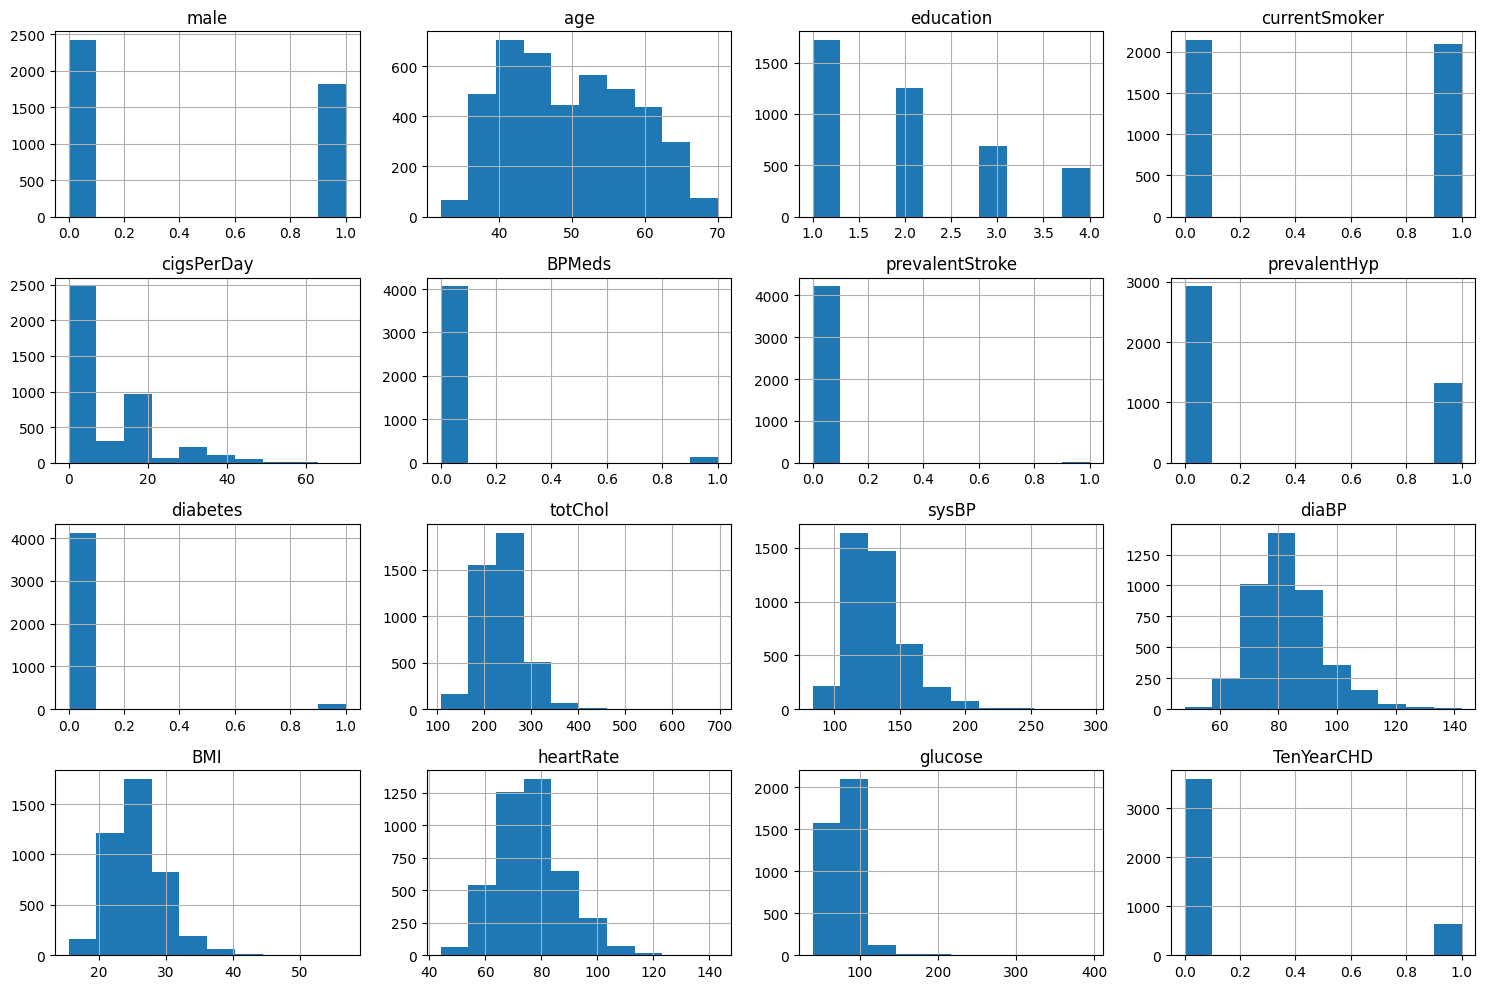

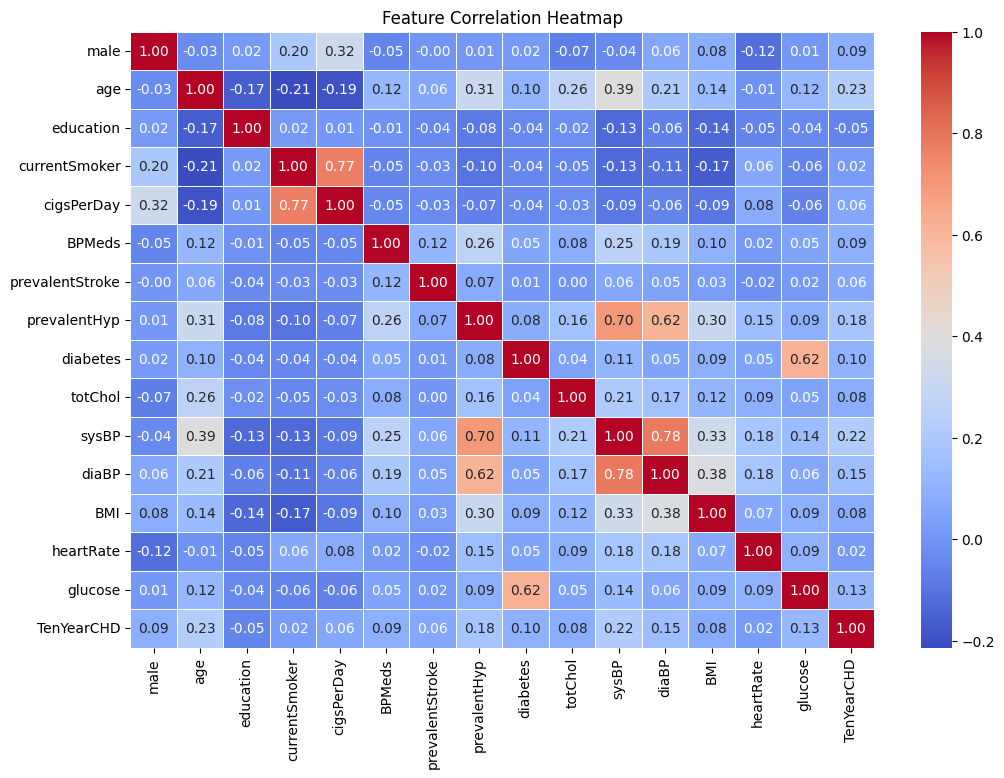

In [ ]:
# Check class balance
print("Target Class Distribution:")
print(df['TenYearCHD'].value_counts())

# Plot histograms for all features
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# Calculate and visualize correlations
correlation = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Features selecting - Using all available features for maximum accuracy
y = df_clean['TenYearCHD']
X = df_clean.drop('TenYearCHD', axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing features to improve Logistic Regression accuracy
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Target variable: TenYearCHD")
print(f"Features used: {list(X.columns)}")
print(f"Number of features: {X.shape[1]}")
print("Data split and scaling complete.")

Target variable: TenYearCHD
Features used: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Number of features: 15
Data split and scaling complete.


In [ ]:
# Train the Logistic Regression model to learn the relationship
# between patient features and the risk of heart disease.
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# model prediction
y_pred = model.predict(X_test)
#Probability of each class
y_prob = model.predict_proba(X_test)

# Probability of positive class
positive_probability = y_prob[:,1]



In [ ]:
# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print (f'Accuracy of the model :{accuracy}')

print(classification_report(y_test, y_pred))



Accuracy of the model :0.8360655737704918
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       610
           1       0.56      0.08      0.14       122

    accuracy                           0.84       732
   macro avg       0.70      0.53      0.53       732
weighted avg       0.80      0.84      0.78       732



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,age,0.584404
10,sysBP,0.341743
0,male,0.315451
4,cigsPerDay,0.177188
14,glucose,0.140442
9,totChol,0.132474
7,prevalentHyp,0.107759
3,currentSmoker,0.105753
6,prevalentStroke,0.065171
8,diabetes,0.063242


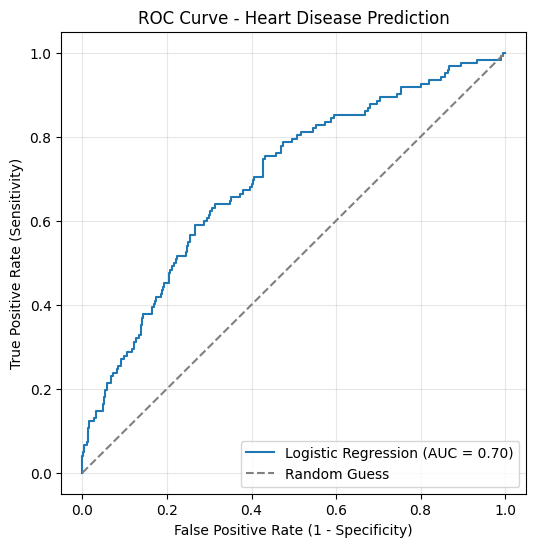

The AUC Score is 0.6994. This indicates the model has a high probability of ranking a random positive case higher than a random negative one.


In [ ]:
# Visualize ROC Curve with AUC Score
# ==========================================================

fpr, tpr, thresholds = roc_curve(y_test, positive_probability)
roc_auc = roc_auc_score(y_test, positive_probability)

plt.figure(figsize=(6,6))

# Plot the curve and label it with the AUC score
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')

# Plot the random chance line
plt.plot([0,1],[0,1],'--', color='gray', label='Random Guess')

plt.xlabel("False Positive Rate (1 - Specificity)")

plt.ylabel("True Positive Rate (Sensitivity)")

plt.title("ROC Curve - Heart Disease Prediction")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

print(f"The AUC Score is {roc_auc:.4f}. This indicates the model has a high probability of ranking a random positive case higher than a random negative one.")

In [ ]:
# Define a new sample (you can change these values to test different scenarios)
new_sample = {
    'male': 1,
    'age': 45,
    'education': 2.0,
    'currentSmoker': 1,
    'cigsPerDay': 20.0,
    'BPMeds': 0.0,
    'prevalentStroke': 0,
    'prevalentHyp': 1,
    'diabetes': 0,
    'totChol': 220.0,
    'sysBP': 140.0,
    'diaBP': 90.0,
    'BMI': 28.5,
    'heartRate': 75.0,
    'glucose': 85.0
}

# 1. Convert to DataFrame (this ensures feature names and order match)
new_df = pd.DataFrame([new_sample])

# 2. Scale the data using the ALREADY FITTED scaler
new_sample_scaled = scaler.transform(new_df)

# 3. Make the prediction
prediction = model.predict(new_sample_scaled)
probability = model.predict_proba(new_sample_scaled)

print(f"Prediction for new sample: {'Risk of CHD' if prediction[0] == 1 else 'No Risk of CHD'}")
print(f"Probability of Heart Disease: {probability[0][1]*100:.2f}%")

Prediction for new sample: No Risk of CHD
Probability of Heart Disease: 17.54%


my  dataset has many more healthy people than sick people, the model learns that it can get high accuracy just by saying 'No Risk' every time.

In [ ]:
# Fix: Convert dictionary to DataFrame before transforming
new_sample_df = pd.DataFrame([new_sample])

# Scale the data
new_sample_scaled = scaler.transform(new_sample_df)

print("--- Prediction Results ---")
print(f"Class Prediction: {prediction[0]}")
print(f"Status: {'Risk of CHD' if prediction[0] == 1 else 'No Risk of CHD'}")

print("\n--- Probabilities ---")
print(f"No Risk (0): {probability[0][0]:.4f}")
print(f"Risk (1): {probability[0][1]:.4f}")

--- Prediction Results ---
Class Prediction: 0
Status: No Risk of CHD

--- Probabilities ---
No Risk (0): 0.8246
Risk (1): 0.1754


In [ ]:
import joblib
import os
from google.colab import files

# 1. Create the models directory
os.makedirs('models', exist_ok=True)

# 2. Save the components requested
joblib.dump(model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(list(X.columns), "models/features.pkl")

# 3. Create a copy specifically for downloading with the requested name
joblib.dump(model, 'heartdisease.pkl')

print("Artifacts saved to 'models/' folder.")

# 4. Trigger download
files.download('heartdisease.pkl')

Artifacts saved to 'models/' folder.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>